In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
!pip install pandas pillow

In [3]:
!pip install pandas
!pip install opencv-python

In [4]:
!pip install tensorflow==2.12.0
!pip install keras

INFO: pip is looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 586.0/586.0 MB 2.9 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 56.0 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 67.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 90.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 95.0 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 440.7/440.7 kB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.6/79.6 MB 21.3 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: wrapt
    Found 

In [6]:
!pip install -q datasets

In [7]:
import numpy as np
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import cv2
import os
from tensorflow import keras
import glob as gb
import pandas as pd
from tensorflow.keras.preprocessing import image_dataset_from_directory
# Import RandomFlip and RandomRotation from the preprocessing module
from tensorflow.keras.layers.experimental.preprocessing import RandomFlip, RandomRotation
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.layers import Conv2D, MaxPool2D, LeakyReLU

In [8]:
from tensorflow.keras.preprocessing import image_dataset_from_directory

# Set image size for ResNet-50 (224x224)
IMG_SIZE = (224, 224)  # ResNet-50 default resolution
directory = "/kaggle/input/cauliflower-augmented"
BATCH_SIZE = 128

# Load training dataset
train_dataset = image_dataset_from_directory(
    directory,
    shuffle=True,
    labels='inferred',
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,  # Updated for ResNet-50
    validation_split=0.1,
    subset='training',
    color_mode='rgb',
    seed=42
)

# Load validation dataset
validation_dataset = image_dataset_from_directory(
    directory,
    shuffle=True,
    labels='inferred',
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,  # Updated for ResNet-50
    validation_split=0.1,
    subset='validation',
    color_mode='rgb',
    seed=42
)

Found 7249 files belonging to 4 classes.
Using 6525 files for training.
Found 7249 files belonging to 4 classes.
Using 724 files for validation.


In [10]:
class_names = train_dataset.class_names
class_names

['Bacterial spot rot', 'Black Rot', 'Downy Mildew', 'Healthy']

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


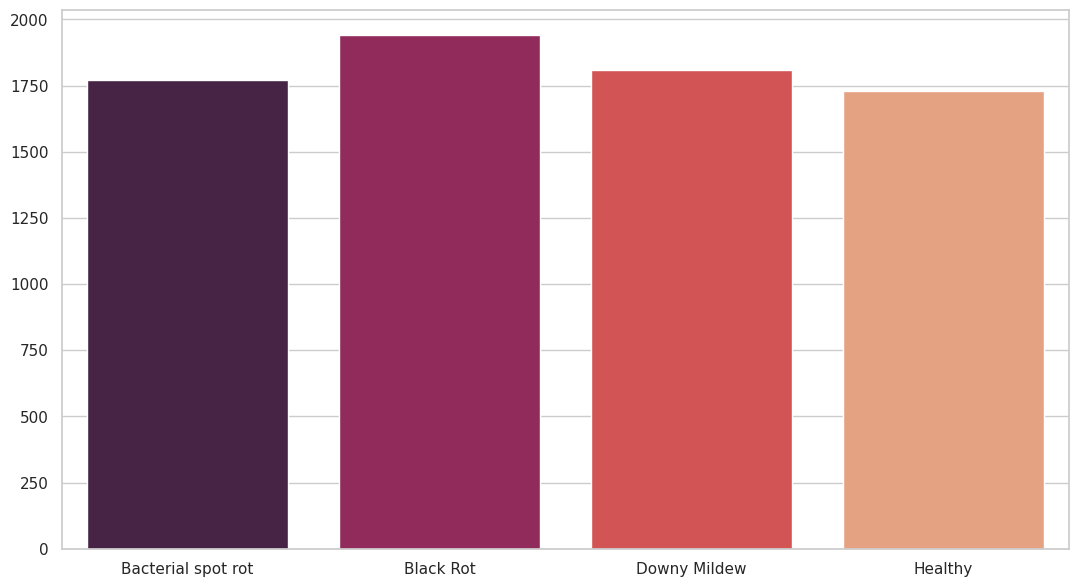

In [11]:
import os
import glob as gb
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Initialize list for storing data imbalance info
Data_imbalance = []

# Loop through each class folder and count the number of images
for folder in os.listdir(directory):
    files = gb.glob(pathname=str(directory + "/" + folder + "/*.*"))
    Data_imbalance.append(len(files))

# Plot data imbalance
plt.figure(figsize=(13, 7))
sns.barplot(
    x=['Bacterial spot rot', 'Black Rot', 'Downy Mildew', 'Healthy'],
    y=Data_imbalance,
    palette="rocket"
)
plt.show()

In [12]:
total = 0
for i in range(0,len(Data_imbalance)) :
    total +=Data_imbalance[i]

weight_for_0 = (1 / Data_imbalance[0]) * (total / 4.0)
weight_for_1 = (1 / Data_imbalance[1]) * (total / 4.0)
weight_for_2 = (1 / Data_imbalance[2]) * (total / 4.0)
weight_for_3 = (1 / Data_imbalance[3]) * (total / 4.0)

class_weight = {0: weight_for_0, 1: weight_for_1, 2: weight_for_2, 3: weight_for_3}

print('Weight for class 0: {:.2f}'.format(weight_for_0))
print('Weight for class 1: {:.2f}'.format(weight_for_1))
print('Weight for class 2: {:.2f}'.format(weight_for_2))
print('Weight for class 3: {:.2f}'.format(weight_for_3))

Weight for class 0: 1.02
Weight for class 1: 0.93
Weight for class 2: 1.00
Weight for class 3: 1.05


In [13]:
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip("horizontal"),
  tf.keras.layers.RandomRotation(0.2),
  tf.keras.layers.RandomZoom(0.2),
  tf.keras.layers.RandomHeight(0.2),
  tf.keras.layers.RandomWidth(0.2),
])

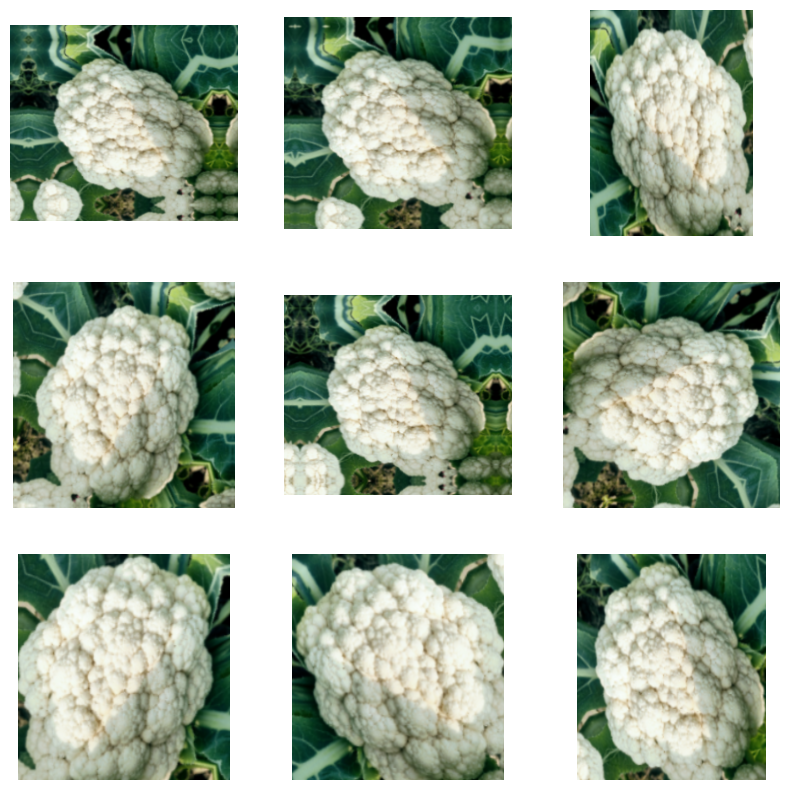

In [14]:
for image, _ in train_dataset.take(1):
    plt.figure(figsize=(10, 10))
    first_image = image[0]
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        augmented_image = data_augmentation(tf.expand_dims(first_image, 0))
        plt.imshow(augmented_image[0] / 255)
        plt.axis('off')

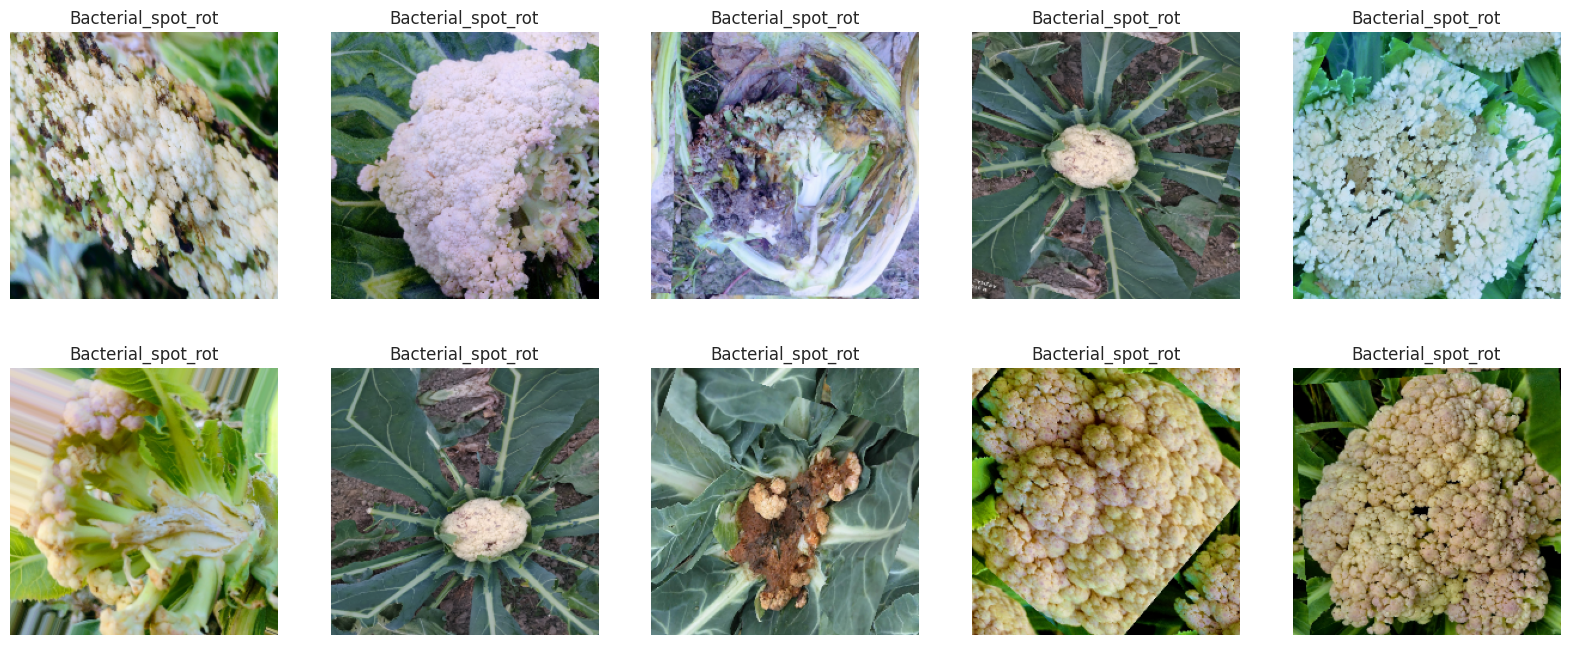

In [15]:
plt.figure(figsize=(20,8))
Bacterial_spot_rot = []
Black_Rot= []
Downy_Mildew =[]


for images , labels in train_dataset.take(1):
    for i in range(100):
        if class_names[labels[i]] == "Bacterial spot rot":
            Bacterial_spot_rot.append(images[i].numpy().astype("uint8"))
        if  class_names[labels[i]] == "Black Rot":
            Black_Rot.append(images[i].numpy().astype("uint8"))
        if  class_names[labels[i]] == "Downy Mildew":
           Downy_Mildew.append(images[i].numpy().astype("uint8"))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(Bacterial_spot_rot[i])
    plt.axis("off")
    plt.title("Bacterial_spot_rot")

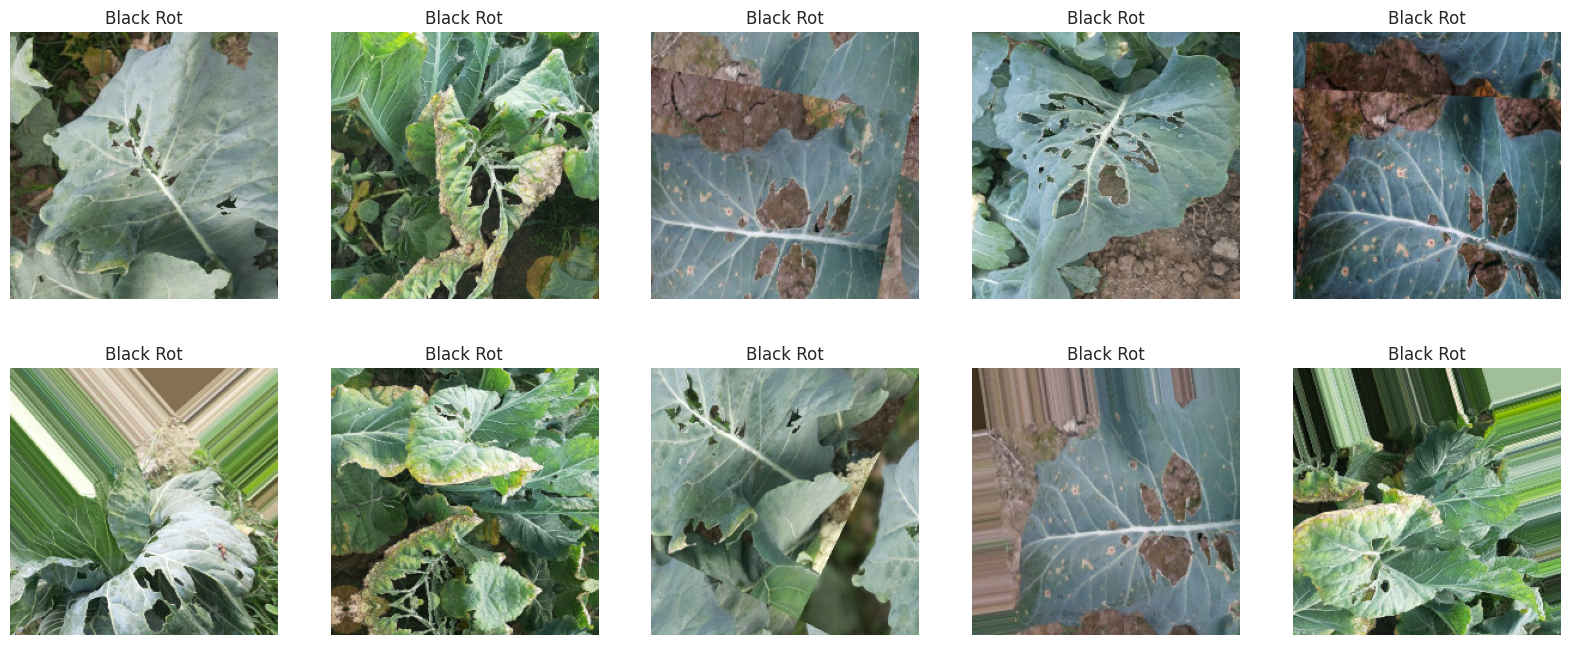

In [16]:
plt.figure(figsize=(20,8))
for i in range(min(10, len(Black_Rot))): # Changed to display up to 10 or the available images
    plt.subplot(2,5,i+1)
    plt.imshow(Black_Rot[i])
    plt.axis("off")
    plt.title("Black Rot")

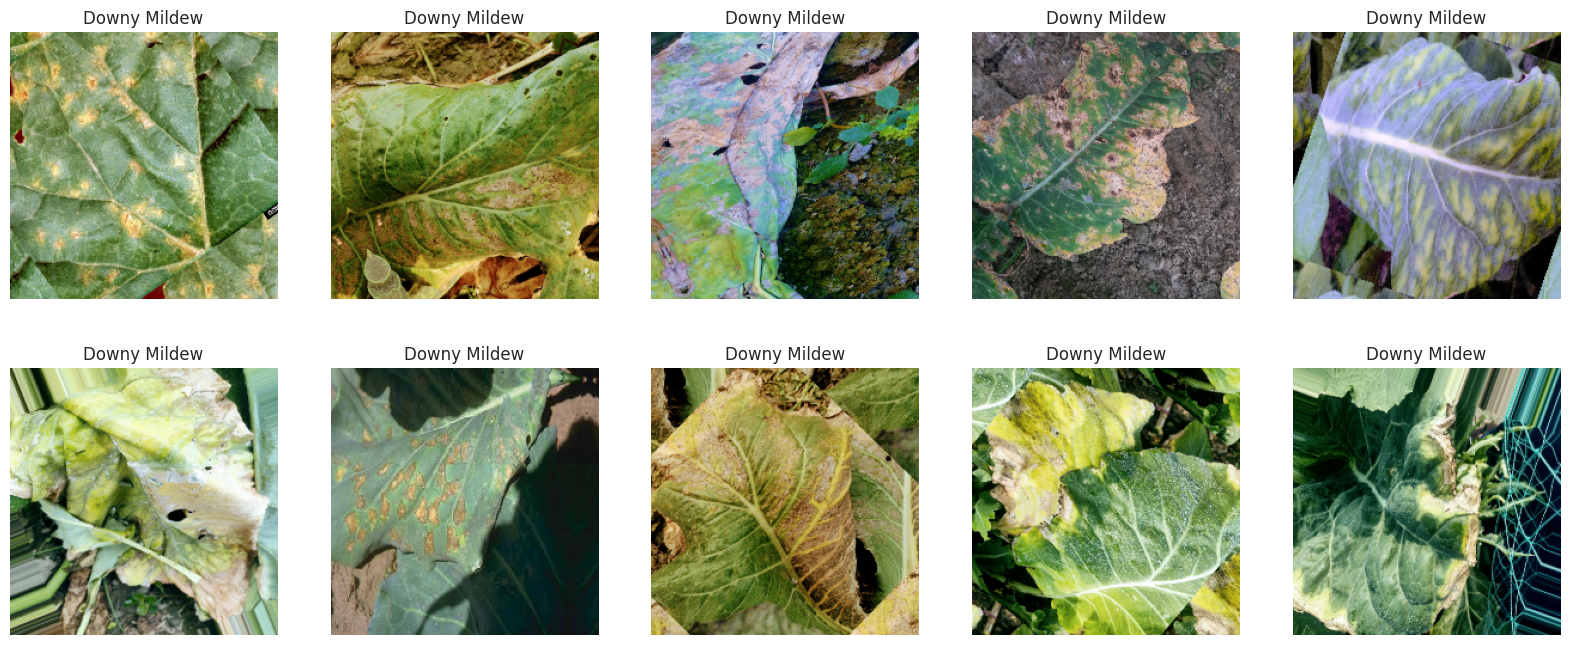

In [17]:
plt.figure(figsize=(20,8))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(Downy_Mildew[i])
    plt.axis("off")
    plt.title("Downy Mildew")

In [18]:
import tensorflow as tf

# Enable automatic prefetching for better performance
AUTOTUNE = tf.data.AUTOTUNE  # Updated to tf.data.AUTOTUNE (latest TensorFlow versions)

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)  # Apply to validation dataset too

In [19]:
from tensorflow.keras.applications import VGG19
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

# Load VGG19 base model with ImageNet weights
base_model = VGG19(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze base model layers
base_model.trainable = False

# Add custom classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
predictions = Dense(len(class_names), activation='softmax')(x)

# Final model
model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Summary
model.summary()


80134624/80134624 [==============================] - 3s 0us/step
Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                              

In [21]:
EPOCHS = 10

history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS,
    class_weight=class_weight  # Use the computed class weights to handle imbalance
)


Epoch 1/10
51/51 [==============================] - 1587s 31s/step - loss: 0.2276 - accuracy: 0.9195 - val_loss: 0.1044 - val_accuracy: 0.9765
Epoch 2/10
51/51 [==============================] - 1601s 31s/step - loss: 0.1935 - accuracy: 0.9336 - val_loss: 0.0922 - val_accuracy: 0.9765
Epoch 3/10
51/51 [==============================] - 1633s 32s/step - loss: 0.1808 - accuracy: 0.9362 - val_loss: 0.0816 - val_accuracy: 0.9793
Epoch 4/10
51/51 [==============================] - 1602s 31s/step - loss: 0.1615 - accuracy: 0.9436 - val_loss: 0.0717 - val_accuracy: 0.9807
Epoch 5/10
51/51 [==============================] - 1576s 31s/step - loss: 0.1467 - accuracy: 0.9494 - val_loss: 0.0637 - val_accuracy: 0.9820
Epoch 6/10
51/51 [==============================] - 1629s 32s/step - loss: 0.1304 - accuracy: 0.9579 - val_loss: 0.0580 - val_accuracy: 0.9834
Epoch 7/10
51/51 [==============================] - 1636s 32s/step - loss: 0.1160 - accuracy: 0.9595 - val_loss: 0.0541 - val_accuracy: 0.9834

In [ ]:
# Evaluate on the validation dataset
val_loss, val_accuracy = model.evaluate(validation_dataset)
print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")


In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='green')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='blue')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', color='red')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


NameError: name 'history' is not defined

In [7]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Get true labels and predictions
y_true = []
y_pred = []

for images, labels in validation_dataset:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


NameError: name 'validation_dataset' is not defined

In [8]:
# Classification Report
report = classification_report(y_true, y_pred, target_names=class_names)
print("Classification Report:\n")
print(report)


NameError: name 'class_names' is not defined